# ***STARTUP SUCCESS PREDICTION MACHINE LEARNING PROJECT***

# LOADING DATASET

In [ ]:
import pandas as pd

try:
    df = pd.read_csv('data.csv', encoding='latin-1')
    display(df.head())
except UnicodeDecodeError:
    print("Could not decode the file with 'latin-1' encoding either. Please check the file encoding.")


,Company_Name,Dependent-Company Status,year of founding,Age of company in years,Internet Activity Score,Short Description of company profile,Industry of company,Focus functions of company,Investors,Employee Count,...,Percent_skill_Data Science,Percent_skill_Business Strategy,Percent_skill_Product Management,Percent_skill_Sales,Percent_skill_Domain,Percent_skill_Law,Percent_skill_Consulting,Percent_skill_Finance,Percent_skill_Investment,Renown score
0,Company1,Success,No Info,No Info,-1.0,Video distribution,NaN,operation,KPCB Holdings|Draper Fisher Jurvetson (DFJ)|Kl...,3.0,...,0,0,0,0,0,0,0,0,0,0
1,Company2,Success,2011,3,125.0,NaN,Market Research|Marketing|Crowdfunding,"Marketing, sales",NaN,NaN,...,8.823529412,21.76470588,10.88235294,2.941176471,0,0,0,0,0,8
2,Company3,Success,2011,3,455.0,Event Data Analytics API,Analytics|Cloud Computing|Software Development,operations,TechStars|Streamlined Ventures|Amplify Partner...,14.0,...,3.846153846,17.09401709,9.401709402,0,2.777777778,0,0,0,0,9
3,Company4,Success,2009,5,-99.0,The most advanced analytics for mobile,Mobile|Analytics,Marketing & Sales,Michael Birch|Max Levchin|Sequoia Capital|Keit...,45.0,...,0,0,0,0,0,0,0,0,0,5
4,Company5,Success,2010,4,496.0,The Location-Based Marketing Platform,Analytics|Marketing|Enterprise Software,Marketing & Sales,DFJ Frontier|Draper Nexus Ventures|Gil Elbaz|A...,39.0,...,0,0,0,0,0,0,0,0,0,6


# DISPLAY WHOLE DATASET

In [ ]:
display(df)

,Company_Name,Dependent-Company Status,year of founding,Age of company in years,Internet Activity Score,Short Description of company profile,Industry of company,Focus functions of company,Investors,Employee Count,...,Percent_skill_Data Science,Percent_skill_Business Strategy,Percent_skill_Product Management,Percent_skill_Sales,Percent_skill_Domain,Percent_skill_Law,Percent_skill_Consulting,Percent_skill_Finance,Percent_skill_Investment,Renown score
0,Company1,Success,No Info,No Info,-1.0,Video distribution,NaN,operation,KPCB Holdings|Draper Fisher Jurvetson (DFJ)|Kl...,3.0,...,0,0,0,0,0,0,0,0,0,0
1,Company2,Success,2011,3,125.0,NaN,Market Research|Marketing|Crowdfunding,"Marketing, sales",NaN,NaN,...,8.823529412,21.76470588,10.88235294,2.941176471,0,0,0,0,0,8
2,Company3,Success,2011,3,455.0,Event Data Analytics API,Analytics|Cloud Computing|Software Development,operations,TechStars|Streamlined Ventures|Amplify Partner...,14.0,...,3.846153846,17.09401709,9.401709402,0,2.777777778,0,0,0,0,9
3,Company4,Success,2009,5,-99.0,The most advanced analytics for mobile,Mobile|Analytics,Marketing & Sales,Michael Birch|Max Levchin|Sequoia Capital|Keit...,45.0,...,0,0,0,0,0,0,0,0,0,5
4,Company5,Success,2010,4,496.0,The Location-Based Marketing Platform,Analytics|Marketing|Enterprise Software,Marketing & Sales,DFJ Frontier|Draper Nexus Ventures|Gil Elbaz|A...,39.0,...,0,0,0,0,0,0,0,0,0,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
467,Company468,Failed,2011,3,-5.0,BtoB deal site,E-Commerce,NaN,NaN,NaN,...,No Info,No Info,No Info,No Info,No Info,No Info,No Info,No Info,No Info,No Info
468,Company469,Failed,No Info,NaN,NaN,NaN,NaN,consumer web,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
469,Company470,Failed,2010,4,0.0,Real Time Social Media Analytics,Analytics|E-Commerce,CAMPAIGN MANAGEMENT,NaN,0.0,...,No Info,No Info,No Info,No Info,No Info,No Info,No Info,No Info,No Info,No Info
470,Company471,Failed,2009,5,0.0,Social Media Publishing and Analytics,Analytics|Marketing,SOCIALMEDIA CAMPAIGN,NaN,NaN,...,No Info,No Info,No Info,No Info,No Info,No Info,No Info,No Info,No Info,No Info


# IMPORTING LIBRARIES

CLEANING DATA

TEST , TRAIN , SPLIT DATASET

Dataset loaded successfully.
  Company_Name Dependent-Company Status year of founding  \
0     Company1                  Success          No Info   
1     Company2                  Success             2011   
2     Company3                  Success             2011   
3     Company4                  Success             2009   
4     Company5                  Success             2010   

  Age of company in years  Internet Activity Score  \
0                 No Info                     -1.0   
1                       3                    125.0   
2                       3                    455.0   
3                       5                    -99.0   
4                       4                    496.0   

     Short Description of company profile  \
0                      Video distribution   
1                                     NaN   
2                Event Data Analytics API   
3  The most advanced analytics for mobile   
4   The Location-Based Marketing Platform   

              

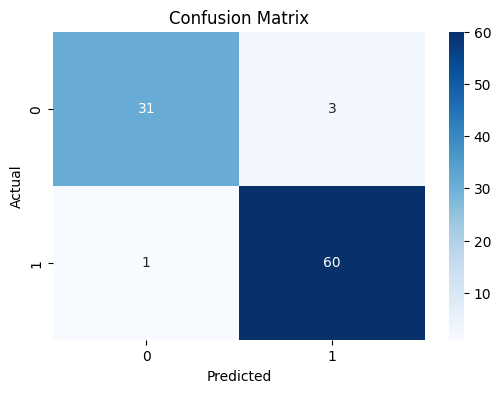

/tmp/ipykernel_1388/3065675394.py:103: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_features.values, y=top_features.index, palette="viridis")


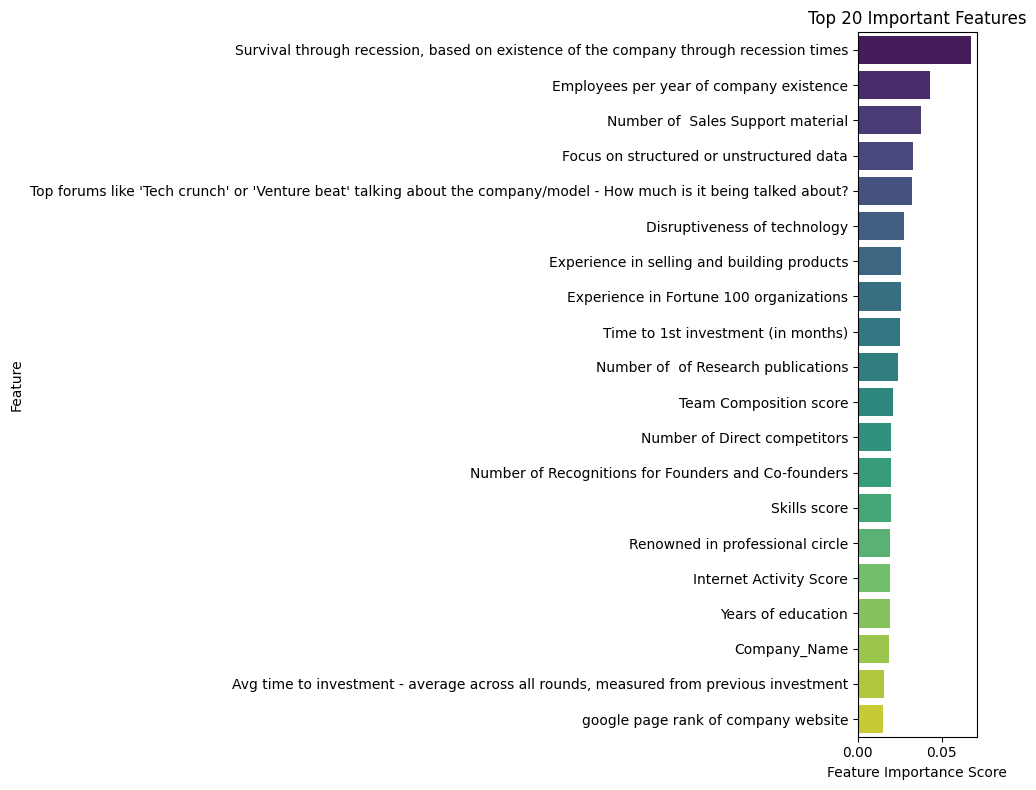

In [ ]:
# Step 1: Import Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer # Corrected import
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Step 2: Load Uploaded Dataset

print("Dataset loaded successfully.")
print(df.head())

# Step 3: Understand Dataset
print("\nShape:", df.shape)
print("\nMissing Values:\n", df.isnull().sum())
print("\nTarget Value Counts:\n", df['Dependent-Company Status'].value_counts())  # Assuming target column is 'Dependent-Company Status'

# Step 4: Clean and Encode

# Replace 'No Info' with NaN and convert to numeric for relevant columns
cols_to_convert_numeric = [col for col in df.columns if 'Percent_skill' in col or col == 'Renown score' or col == 'Age of company in years' or col == 'year of founding']
for col in cols_to_convert_numeric:
    if df[col].dtype == 'object':
        df[col] = df[col].replace('No Info', np.nan)
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Separate features and target
X = df.drop('Dependent-Company Status', axis=1)
y = df['Dependent-Company Status']

# Identify categorical and numerical columns BEFORE imputation
categorical_cols = X.select_dtypes(include='object').columns
numerical_cols = X.select_dtypes(include=np.number).columns

# Impute missing values
# Impute numerical columns with the mean
numerical_imputer = SimpleImputer(strategy='mean')
X[numerical_cols] = numerical_imputer.fit_transform(X[numerical_cols])

# Impute categorical columns with a constant value (e.g., 'Missing')
categorical_imputer = SimpleImputer(strategy='constant', fill_value='Missing')
# Only apply if there are categorical columns
if len(categorical_cols) > 0:
    X[categorical_cols] = categorical_imputer.fit_transform(X[categorical_cols])

# Print shape after cleaning and encoding
print("\nShape after cleaning and encoding:", X.shape)

# Label encode categorical features
# Only apply if there are categorical columns
if len(categorical_cols) > 0:
    label_encoders = {}
    for col in categorical_cols:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col])
        label_encoders[col] = le


# Encode target column
target_le = LabelEncoder()
y = target_le.fit_transform(y)  # 1 = Success, 0 = Failed


# Step 5: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

# Step 6: Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Step 7: Train Classifier
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Step 8: Evaluate
y_pred = model.predict(X_test)
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Step 9: Clean Feature Importance Plot
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)

# Show top 20 features only (you can change this number)
top_n = 20
top_features = importances.head(top_n)

plt.figure(figsize=(10, 8))
sns.barplot(x=top_features.values, y=top_features.index, palette="viridis")
plt.title(f"Top {top_n} Important Features")
plt.xlabel("Feature Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()









# PREDICTING

In [ ]:
# Step 1: Prepare new data for prediction

# Create a dictionary with the new startup's data.
# Fill in the relevant details for your startup.
# Use 'Missing' for categorical features and np.nan for numerical features if the data is unavailable.
new_startup_data = {
    'year of founding': 2022,
    'Age of company in years': 2,
    'Internet Activity Score': 114.159705, # Example: using the mean from training data
    'Short Description of company profile': 'Missing',
    'Industry of company': 'Missing',
    'Focus functions of company': 'Missing',
    'Investors': 'Missing',
    'Employee Count': 31.408497, # Example: using the mean from training data
    'Employees count MoM change': -1.299625, # Example: using the mean from training data
    'Has the team size grown': 'Missing',
    'Est. Founding Date': 'Missing',
    'Last Funding Date': 'Missing',
    'Last Funding Amount': 0.0, # Example: using the mean from training data
    'Country of company': 'Missing',
    'Continent of company': 'Missing',
    'Number of Investors in Seed': 0.0, # Example: using the mean from training data
    'Number of Investors in Angel and or VC': 0.0, # Example: using the mean from training data
    'Number of Co-founders': 0.0, # Example: using the mean from training data
    'Number of of advisors': 0.0, # Example: using the mean from training data
    'Team size Senior leadership': 0.0, # Example: using the mean from training data
    'Team size all employees': 'Missing',
    'Presence of a top angel or venture fund in previous round of investment': 'Missing',
    'Number of of repeat investors': 0.0, # Example: using the mean from training data
    'Number of  Sales Support material': 0.0, # Example: using the mean from training data
    'Worked in top companies': 'Missing',
    'Average size of companies worked for in the past': 0.0, # Example: using the mean from training data
    'Have been part of startups in the past?': 'Missing',
    'Have been part of successful startups in the past?': 'Missing',
    'Was he or she partner in Big 5 consulting?': 'Missing',
    'Consulting experience?': 'Missing',
    'Product or service company?': 'Missing',
    'Catering to product/service across verticals': 'Missing',
    'Focus on private or public data?': 'Missing',
    'Focus on consumer data?': 'Missing',
    'Focus on structured or unstructured data': 'Missing',
    'Subscription based business': 'Missing',
    'Cloud or platform based serive/product?': 'Missing',
    'Local or global player': 'Missing',
    'Linear or Non-linear business model': 'Missing',
    'Capital intensive business e.g. e-commerce, Engineering products and operations can also cause a business to be capital intensive': 'Missing',
    'Number of  of Partners of company': 0.0, # Example: using the mean from training data
    'Crowdsourcing based business': 'Missing',
    'Crowdfunding based business': 'Missing',
    'Machine Learning based business': 'Missing',
    'Predictive Analytics business': 'Missing',
    'Speech analytics business': 'Missing',
    'Prescriptive analytics business': 'Missing',
    'Big Data Business': 'Missing',
    'Cross-Channel Analytics/ marketing channels': 'Missing',
    'Owns data or not? (monetization of data) e.g. Factual': 'Missing',
    'Is the company an aggregator/market place? e.g. Bluekai': 'Missing',
    'Online or offline venture - physical location based business or online venture?': 'Missing',
    'B2C or B2B venture?': 'Missing',
    "Top forums like 'Tech crunch' or 'Venture beat' talking about the company/model - How much is it being talked about?": 0.0, # Example: using the mean from training data
    'Average Years of experience for founder and co founder': 0.0, # Example: using the mean from training data
    'Exposure across the globe': 'Missing',
    'Breadth of experience across verticals': 'Missing',
    'Highest education': 'Missing',
    'Years of education': 0.0, # Example: using the mean from training data
    'Specialization of highest education': 'Missing',
    'Relevance of education to venture': 'Missing',
    'Relevance of experience to venture': 'Missing',
    'Degree from a Tier 1 or Tier 2 university?': 'Missing',
    'Renowned in professional circle': 'Missing',
    'Experience in selling and building products': 'Missing',
    'Experience in Fortune 100 organizations': 'Missing',
    'Experience in Fortune 500 organizations': 'Missing',
    'Experience in Fortune 1000 organizations': 'Missing',
    'Top management similarity': 0.0, # Example: using the mean from training data
    'Number of Recognitions for Founders and Co-founders': 0.0, # Example: using the mean from training data
    'Number of  of Research publications': 0.0, # Example: using the mean from training data
    'Skills score': 0.0, # Example: using the mean from training data
    'Team Composition score': 0.0, # Example: using the mean from training data
    'Dificulty of Obtaining Work force': 'Missing',
    'Pricing Strategy': 'Missing',
    'Hyper localisation': 'Missing',
    'Time to market service or product': 'Missing',
    'Employee benefits and salary structures': 'Missing',
    'Long term relationship with other founders': 'Missing',
    'Proprietary or patent position (competitive position)': 'Missing',
    'Barriers of entry for the competitors': 'Missing',
    'Company awards': 'Missing',
    'Controversial history of founder or co founder': 'Missing',
    'Legal risk and intellectual property': 'Missing',
    'Client Reputation': 'Missing',
    'google page rank of company website': 0.0, # Example: using the mean from training data
    'Technical proficiencies to analyse and interpret unstructured data': 'Missing',
    'Solutions offered': 'Missing',
    'Invested through global incubation competitions?': 'Missing',
    'Industry trend in investing': 0.0, # Example: using the mean from training data
    'Disruptiveness of technology': 'Missing',
    'Number of Direct competitors': 'Missing',
    'Employees per year of company existence': 'Missing',
    'Last round of funding received (in milionUSD)': 'Missing',
    'Survival through recession, based on existence of the company through recession times': 'Missing',
    'Time to 1st investment (in months)': 'Missing',
    'Avg time to investment - average across all rounds, measured from previous investment': 'Missing',
    'Gartner hype cycle stage': 'Missing',
    'Time to maturity of technology (in years)': 'Missing',
    'Percent_skill_Entrepreneurship': 0.0, # Example: using the mean from training data
    'Percent_skill_Operations': 0.0, # Example: using the mean from training data
    'Percent_skill_Engineering': 0.0, # Example: using the mean from training data
    'Percent_skill_Marketing': 0.0, # Example: using the mean from training data
    'Percent_skill_Leadership': 0.0, # Example: using the mean from training data
    'Percent_skill_Data Science': 0.0, # Example: using the mean from training data
    'Percent_skill_Business Strategy': 0.0, # Example: using the mean from training data
    'Percent_skill_Product Management': 0.0, # Example: using the mean from training data
    'Percent_skill_Sales': 0.0, # Example: using the mean from training data
    'Percent_skill_Domain': 0.0, # Example: using the mean from training data
    'Percent_skill_Law': 0.0, # Example: using the mean from training data
    'Percent_skill_Consulting': 0.0, # Example: using the mean from training data
    'Percent_skill_Finance': 0.0, # Example: using the mean from training data
    'Percent_skill_Investment': 0.0, # Example: using the mean from training data
    'Renown score': 0.0, # Example: using the mean from training data
    'Company_Name': 'Missing' # Add Company_Name as it was in X
}

# Convert the dictionary to a DataFrame
new_data = pd.DataFrame([new_startup_data])

# Ensure the new data has the same columns as the training data (X)
# Add missing columns with default values (e.g., mean for numerical, 'Missing' for categorical)
for col in X.columns:
    if col not in new_data.columns:
        if col in numerical_cols:
            new_data[col] = X[col].mean() # Use the mean from the training data
        else:
            new_data[col] = 'Missing'

# Reorder columns to match the training data
new_data = new_data[X.columns]

# Step 2: Preprocess the new data

# Impute missing values (using the same imputers fitted on the training data)
new_data[numerical_cols] = numerical_imputer.transform(new_data[numerical_cols])

# Only apply if there are categorical columns
if len(categorical_cols) > 0:
    new_data[categorical_cols] = categorical_imputer.transform(new_data[categorical_cols])

# Label encode categorical features (using the same encoders fitted on the training data)
# Only apply if there are categorical columns
if len(categorical_cols) > 0:
    for col in categorical_cols:
        # Handle potential new categories not seen during training
        new_data[col] = new_data[col].apply(lambda x: x if x in label_encoders[col].classes_ else 'Missing')
        label_encoders[col].classes_ = np.append(label_encoders[col].classes_, 'Missing') # Add 'Missing' to classes if not present
        new_data[col] = label_encoders[col].transform(new_data[col])


# Scale the new data (using the same scaler fitted on the training data)
new_data_scaled = scaler.transform(new_data)

# Step 3: Make a prediction
prediction = model.predict(new_data_scaled)

# Step 4: Interpret the prediction
predicted_status = target_le.inverse_transform(prediction)

# Step 5: Output the prediction
print("\nPredicted Company Status:", predicted_status[0])


Predicted Company Status: Failed


In [ ]:

new_startup_features = new_data.iloc[0]

# Get the top features from the feature importance plot
top_features = importances.head(top_n)

# Print the values of the top features for the new startup
print("\nValues of the Top Important Features for the New Startup:")
for feature in top_features.index:
    if feature in new_startup_features:
        print(f"{feature}: {new_startup_features[feature]}")
    else:
        print(f"{feature}: Not available in new startup data (this should not happen if preprocessing was correct)")

# Based on the values of these top features, discuss how they align with a 'Success' prediction
# For example, if 'Survival through recession' is a top feature and the new startup has a high value for it (or is marked as 'Not Applicable' in a way that implies resilience), this would support a 'Success' prediction.
# Similarly, if 'Employees per year of company existence' is high, it might indicate strong growth, aligning with 'Success'.

# Step 3: Discuss confidence in the prediction
print("\nConfidence in the prediction:")
print(f"Overall Accuracy of the model: {accuracy_score(y_test, y_pred):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Interpret the accuracy and classification report:
# - High accuracy (e.g., > 0.85) suggests the model performs well overall.
# - Precision, Recall, and F1-score for both classes ('Failed' and 'Success') are important.
# - High precision for 'Success' means when the model predicts 'Success', it's often correct.
# - High recall for 'Success' means the model identifies most of the actual 'Success' cases.
# - The balance between precision and recall (F1-score) gives a better picture.
# - The confusion matrix visually shows correct and incorrect predictions for each class.

# Step 4: Explain what the predicted status means for the hypothetical new startup
print("This prediction is influenced by the specific values of the startup's characteristics, particularly those identified as important features by the model (as shown in the feature importance plot).")
print("While the model shows good overall performance (refer to Accuracy and Classification Report), this is still a prediction based on patterns in the training data and does not guarantee the actual outcome.")
print("The confidence in this specific prediction depends on how well the new startup's characteristics align with the patterns observed in the 'Success' class of the training data, especially for the most influential features.")



Values of the Top Important Features for the New Startup:
Survival through recession, based on existence of the company through recession times: 4.0
Employees per year of company existence: 113.0
Number of  Sales Support material: 6.0
Focus on structured or unstructured data: 6.0
Top forums like 'Tech crunch' or 'Venture beat' talking about the company/model - How much is it being talked about?: 5.0
Disruptiveness of technology: 4.0
Experience in selling and building products: 5.0
Experience in Fortune 100 organizations: 3.0
Time to 1st investment (in months): 52.0
Number of  of Research publications: 4.0
Team Composition score: 4.0
Number of Direct competitors: 24.0
Number of Recognitions for Founders and Co-founders: 123.0
Skills score: 70.0
Renowned in professional circle: 53.0
Internet Activity Score: 114.159705
Years of education: 4.0
Company_Name: 472.0
Avg time to investment - average across all rounds, measured from previous investment: 158.0
google page rank of company websit

### DOWNLOADING MODEL FROM COLAB


In [ ]:
import pickle

with open("model.pkl", "wb") as f:
    pickle.dump(model, f)

In [ ]:
from google.colab import files
files.download("model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>